In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
# ==========================================
# Import Required Libraries
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
# Display first five rows

df.head()

NameError: name 'df' is not defined

In [ ]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("archive (1).zip")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [ ]:
# Display first five rows

df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [ ]:
# Dataset Shape

print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

Rows : 72134
Columns : 4


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
title,558
text,39
label,0


In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
df['label'].value_counts()

,count
label,
1,37106
0,35028


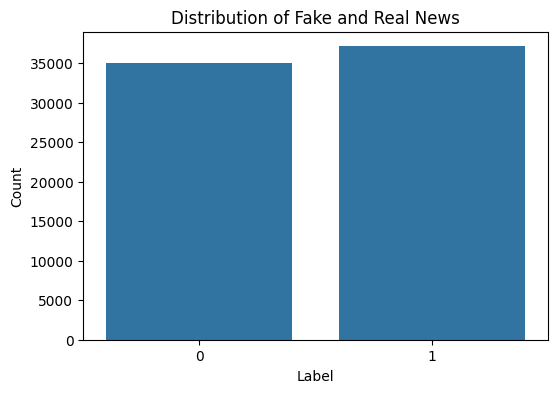

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Distribution of Fake and Real News")

plt.xlabel("Label")

plt.ylabel("Count")

plt.show()

In [ ]:
# Remove Missing Values

df = df.dropna()

print(df.shape)

(71537, 4)


In [ ]:
df = df.drop_duplicates()

print(df.shape)

(71537, 4)


In [ ]:
df["content"] = df["title"] + " " + df["text"]

df = df[["content", "label"]]

df.head()

KeyError: 'title'

In [ ]:
df["content"] = df["title"] + " " + df["text"]

df = df[["content", "label"]]

df.head()

KeyError: 'title'

In [ ]:
print(df.columns)

Index(['content', 'label'], dtype='object')


In [ ]:
df.head()

,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1
5,About Time! Christian Group Sues Amazon and SP...,1


In [ ]:
# Keep only required columns

df = df[["content", "label"]]

df.head()

,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1
5,About Time! Christian Group Sues Amazon and SP...,1


In [ ]:
# ==========================================
# Train-Test Split
# ==========================================

X = df["content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 57229
Testing Samples  : 14308


In [ ]:
# ==========================================
# TF-IDF Vectorization
# ==========================================

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Shape (Train):", X_train_tfidf.shape)
print("TF-IDF Shape (Test):", X_test_tfidf.shape)

TF-IDF Shape (Train): (57229, 5000)
TF-IDF Shape (Test): (14308, 5000)


In [ ]:
df.columns

Index(['content', 'label'], dtype='object')

In [ ]:
df.head()

,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1
5,About Time! Christian Group Sues Amazon and SP...,1


In [ ]:
df.isnull().sum()

,0
content,0
label,0


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 8416


In [ ]:
(df["content"].str.strip() == "").sum()

np.int64(0)

In [ ]:
for i in range(5):
    print(df["content"].iloc[i])
    print("-"*100)

LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and cops to send a message about the killing of black people in America.One of the F***YoFlag organizers is called  Sunshine.  She has a radio blog show hosted from Texas called,  Sunshine s F***ing Opinion Radio Show. A snapshot of her #FYF911 @LOLatWhiteFear Twitter page at 9:53 p.m. shows that she was urging supporters to  Call now!! #fyf911 tonight we continue to dismantle the illusion of white Below is a SNAPSHOT Twitter Radio Call Invite   #FYF911The radio show aired at 10:00 p.m. eastern standard time.During the show, callers clearly call for  lynching  and  killing  of white people.A 2:39

In [ ]:
df["content"].str.contains("http", case=False, na=False).sum()

np.int64(4783)

In [ ]:
df["content"].str.contains("<", regex=False, na=False).sum()

np.int64(313)

In [ ]:
df["content"].str.len().describe()

,content
count,71537.000000
mean,3370.852356
std,3737.750019
min,14.000000
25%,1490.000000
50%,2516.000000
75%,4156.000000
max,143035.000000


In [ ]:
df.shape

(71537, 2)

In [ ]:
# ==========================================
# Split Features and Labels
# ==========================================

X = df["content"]
y = df["label"]

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

Features Shape: (71537,)
Labels Shape: (71537,)


In [ ]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 57229
Testing Samples : 14308


In [ ]:
# ==========================================
# TF-IDF Vectorization
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape :", X_test_tfidf.shape)

Training Shape: (57229, 5000)
Testing Shape : (14308, 5000)


In [ ]:
# ==========================================
# Logistic Regression Model
# ==========================================

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

print("✅ Logistic Regression Model Trained Successfully")

✅ Logistic Regression Model Trained Successfully


In [ ]:
# ==========================================
# Prediction
# ==========================================

y_pred = lr_model.predict(X_test_tfidf)

print("Prediction Completed")

Prediction Completed


In [ ]:
# ==========================================
# Accuracy
# ==========================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2),"%")

Accuracy : 94.36 %


In [ ]:
# ==========================================
# Precision Recall F1
# ==========================================

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

print("Precision :",round(precision,4))

print("Recall :",round(recall,4))

print("F1 Score :",round(f1,4))

Precision : 0.9382
Recall : 0.9522
F1 Score : 0.9452


In [ ]:
# ==========================================
# Classification Report
# ==========================================

from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7006
           1       0.94      0.95      0.95      7302

    accuracy                           0.94     14308
   macro avg       0.94      0.94      0.94     14308
weighted avg       0.94      0.94      0.94     14308



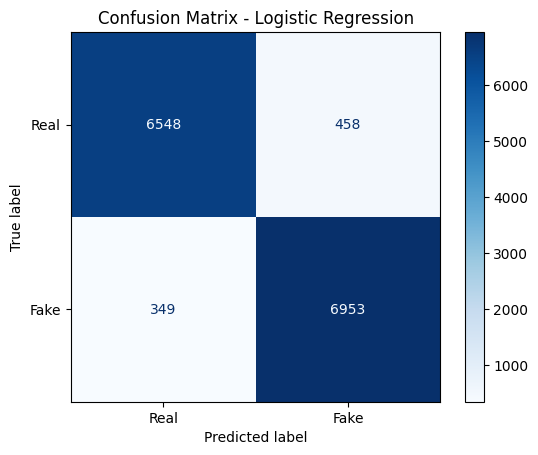

In [ ]:
# ==========================================
# Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real","Fake"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

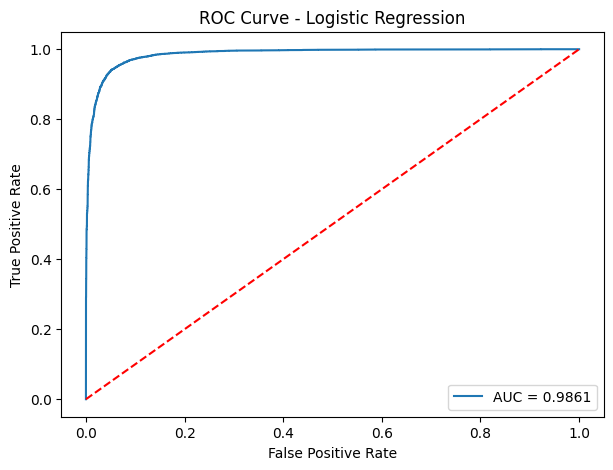

In [ ]:
# ==========================================
# ROC Curve
# ==========================================

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = lr_model.predict_proba(X_test_tfidf)[:,1]

fpr,tpr,threshold = roc_curve(y_test,y_prob)

auc = roc_auc_score(y_test,y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr,label="AUC = %.4f"%auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()